https://github.com/TMuehge/Qiskit-Advocate-Study-Group-2025-2026

https://quantum.cloud.ibm.com/docs/en/guides/execute-on-hardware

https://quantum.cloud.ibm.com/docs/en/guides/primitives

https://quantum.cloud.ibm.com/docs/en/guides/primitive-input-output

https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-session

# Development workflow

The term Qiskit pattern describes the development workflow for breaking down domain-specific problems and contextualizing required capabilities in stages. This allows for the seamless composability of new capabilities developed by IBM Quantum® researchers (and others) and enables a future in which quantum computing tasks are performed by powerful heterogenous (CPU/GPU/QPU) computing infrastructure. Blocks or groups of blocks perform the steps of a pattern, with the Qiskit SDK providing an important foundational layer, supported by other tools or services developed by IBM Quantum or the quantum open-source community. Qiskit patterns allow domain experts to specify a problem and compose the tooling (blocks) that achieves a Qiskit pattern. That pattern can then be executed locally, through cloud services, or deployed with Qiskit Serverless.

The four steps of a Qiskit pattern are as follows:

- Map problem to quantum circuits and operators
- Optimize for target hardware
- Execute on target hardware
- Post-process results

Each step is detailed in the sections below.

# Map the problem to quantum circuits and operators

This step describes how a user starts with a classical problem and figures out how to map it to a quantum computer. For example, in applications such as chemistry and quantum simulation, this step generally involves constructing a quantum circuit representing the Hamiltonian you are attempting to solve. During this step, for certain problems, it might also be desirable to specify the mapping of the problem onto qubits in the heavy-hex (or gross) lattice of IBM® hardware from the outset if the structure of the problem lends itself to optimization earlier. It is also worth considering at this point what the outcome of the particular algorithm will be in preparation for the later execute step - for example, if the desired outcome involves inferring correlation functions using Hadamard tests, you might prepare to use Sampler, whereas specifying observables would use the Estimator and could provide many error mitigation options.

The output of this step is normally a collection of circuits or quantum operators that can be optimized for hardware in the next step.

# Optimize for target hardware

In this step you take the abstract circuits (or operators) produced from the map step and perform a series of optimizations on them. This can include mapping the route and layout of the circuit to physical qubit hardware, converting to basis gates of the hardware, and reducing the number of operations, all designed to optimize the likelihood of success in the later execute step. At this point you might also wish to test out your circuits with a simulator before executing on real hardware in the next step.

During this step, abstract circuits must be transpiled to Instruction Set Architecture (ISA) circuits. An ISA circuit is one that only consists of gates understood by the target hardware (basis gates), and any multi-qubit gates needed to obey any connectivity constraints (coupling map). Only ISA circuits can be run on IBM hardware using IBM Qiskit Runtime.

# Execute on target hardware

This step involves running your circuits on hardware and produces the outputs of the quantum computation. The ISA circuits produced in the previous step can be executed using either a Sampler or Estimator primitive from Qiskit Runtime, initialized locally on your computer or from a cluster or other heterogeneous compute environment. These can be executed in a Batch, which allows parallel transpilation for classical computational efficiency - or a Session, which allows iterative tasks to be implemented efficiently without queuing delays. During this step, there is also the option to configure certain error suppression and mitigation techniques provided by Qiskit Runtime.

Depending on whether you are using the Sampler or Estimator primitive, the outcome of this step will be different. If using the Sampler, the output will be per-shot measurements in the form of bitstrings. If using the Estimator, the output will be expectation values of observables corresponding to physical quantities or cost functions.

# Post-process results

This final step involves stitching the outputs from the prior step back together to obtain the desired result. This can involve a range of classical data-processing steps such as visualizing results, readout error mitigation techniques, marginalizing quasi-probability distributions to ascertain results on smaller sets of qubits, or post-selection on inherent properties of the problem, such as total spin, parity, or particle conservation by removing unphysical observables.

As the field moves from bespoke circuit construction to utility-scale workflows, the flexibility and ease with which Qiskit patterns allow users to compose the different steps of the pattern opens quantum computing to a wide variety of applications and techniques for easy use by quantum computational scientists.

# Primitives

## Why did Qiskit introduce primitives?

Similar to the early days of classical computers, when developers had to manipulate CPU registers directly, the early interface to QPUs simply returned the raw data from the control electronics. This was not a big issue when QPUs lived in labs and only allowed direct access by researchers. Acknowledging that most developers would not and should not be familiar with distilling such raw data into 0s and 1s, Qiskit introduced backend.run, a first abstraction for accessing QPUs in the cloud. This allowed developers to operate on a familiar data format and focus on the bigger picture.

As access to QPUs became more widespread, and with more quantum algorithms being developed, again the need for a higher-level abstraction emerged. In response, Qiskit introduced the primitives interface, which is optimized for two core tasks in quantum algorithm development: expectation value estimation (Estimator) and circuit sampling (Sampler). The goal is once again to help developers to focus more on innovation and less on data conversion. The primitives interface supersedes the backend.run interface, since Sampler provides the same direct hardware access that was offered by backend.run.

### Two core tasks in quantum algorithm development:

- Estimator computes expectation values of observables with respect to states prepared by quantum circuits.
- Sampler samples the output register from quantum circuit execution.

In short, the computational model introduced by the Qiskit primitives moves quantum programming one step closer to where classical programming is today, where the focus is less on the hardware details and more on the results you are trying to achieve.

In quantum mechanics, expectation values represent the average value of a measurable quantity, calculated from the wave function of a system. Expectation values can be used to determine properties such as position and momentum, reflecting the probabilistic nature of quantum mechanics. 

# Get started with Estimator

Open Plan users can use up to 10 minutes of quantum time per 28-day rolling window. Quantum time is the amount of time that the QPU is dedicated to processing your job. You can view an instance's usage on the Instances page.

https://quantum.cloud.ibm.com/instances

1. Initialize the account

In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
 
print(backend.name)

ibm_fez


2. Create a circuit and an observable

### Example: Quantum approximate optimization algorithm (QAOA)

https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm#step-3-execute-using-qiskit-primitives-1

In [2]:
from qiskit.circuit.library import qaoa_ansatz
from qiskit.quantum_info import SparsePauliOp
 
entanglement = [tuple(edge) for edge in backend.coupling_map.get_edges()]
observable = SparsePauliOp.from_sparse_list(
    [("ZZ", [i, j], 0.5) for i, j in entanglement],
    num_qubits=backend.num_qubits,
)
circuit = qaoa_ansatz(observable, reps=2)
# the circuit is parametrized, so we will define the parameter values for execution
param_values = [0.1, 0.2, 0.3, 0.4]
 
print(f">>> Observable: {observable.paulis}")

>>> Observable: ['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...',
 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...', ...]


The circuit and observable need to be transformed to only use instructions supported by the QPU (referred to as instruction set architecture (ISA) circuits). We'll use the transpiler to do this.

In [3]:
from qiskit.transpiler import generate_preset_pass_manager
 
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
isa_observable = observable.apply_layout(isa_circuit.layout)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict([('rz', 4472), ('sx', 1884), ('cz', 1120)])


3. Initialize Qiskit Runtime Estimator

When you initialize the Estimator, use the mode parameter to specify the mode you want it to run in. Possible values are batch, session, or backend objects for batch, session, and job execution mode, respectively. For more information, see Introduction to Qiskit Runtime execution modes.

Here Job mode:

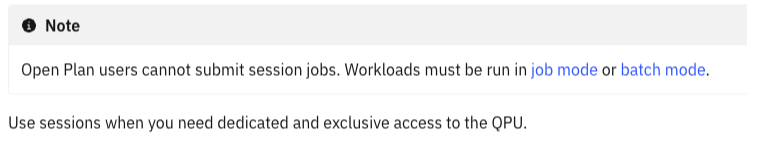

In [4]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
estimator = Estimator(mode=backend)

4. Invoke the Estimator and get results

In [6]:
job = estimator.run([(isa_circuit, isa_observable, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d5ube78husoc73es0f3g
>>> Job Status: QUEUED


In [9]:
result = job.result()
print(f">>> {result}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>)), metadata={'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'resilience': {}, 'num_randomizations': 32})], metadata={'dynamical_decoupling': {'enable': False, 'sequence_type': 'XX', 'extra_slack_distribution': 'middle', 'scheduling_method': 'alap'}, 'twirling': {'enable_gates': False, 'enable_measure': True, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'interleave_randomizations': True, 'strategy': 'active-accum'}, 'resilience': {'measure_mitigation': True, 'zne_mitigation': False, 'pec_mitigation': False}, 'version': 2})
  > Expectation value: 25.104465308194364
  > Metadata: {'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'resilience': {}, 'num_randomizations': 32}


# Get started with Sampler

## 2. Create a circuit

In [7]:
import numpy as np
from qiskit.circuit.library import efficient_su2
 
circuit = efficient_su2(127, entanglement="linear")
circuit.measure_all()
# The circuit is parametrized, so we will define the parameter values for execution
param_values = np.random.rand(circuit.num_parameters)

In [9]:
# circuit.draw("mpl")

Use the transpiler to get an ISA circuit.

In [10]:
from qiskit.transpiler import generate_preset_pass_manager
 
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict([('rz', 3036), ('sx', 1769), ('cz', 378), ('measure', 127), ('barrier', 1)])


## 3. Initialize the Qiskit Runtime Sampler

When you initialize the Sampler, use the mode parameter to specify the mode you want it to run in. Possible values are batch, session, or backend objects for batch, session, and job execution mode, respectively. For more information, see Introduction to Qiskit Runtime execution modes. Note that Open Plan users cannot submit session jobs.

In [11]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
 
sampler = Sampler(mode=backend)

## 4. Invoke the Sampler and get results

In [12]:
job = sampler.run([(isa_circuit, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d5ubf2kbmr9c739o30h0
>>> Job Status: QUEUED


In [11]:
result = job.result()
 
# Get results for the first (and only) PUB
pub_result = result[0]
print(
    f"First ten results for the 'meas' output register: {pub_result.data.meas.get_bitstrings()[:10]}"
)

First ten results for the 'meas' output register: ['0110110111000010010111010000110110100101011000101110101101000101011101011101110111001011101111110010001110010000100111111010100', '0101101110011001100011111011101110111001110011000100011011001010011001011001110010111000010010101000011100010000000011000011100', '0001000110110011011010001010111001010101100111001010111110011000100100001100001010001100110101111101110000101000000011110101000', '0000111011101111100010001001000010010101011000011010010001000110010100100110100000100001001011010000000101001000100001111110100', '1111010101110010100110000000000001010110010101111111100001010101010101011000001110000000100110010011011010110000010100001001100', '1100011001111010010110001001010001110000110110111001100111001001010101010100011111100000000010110001010100100100001100000000100', '0100000001011110011001101010101001101011001101110011100100011010001100000000101000101001011010010111010110110000100110100000000', '0011100010111001100001000010101

# Questions:

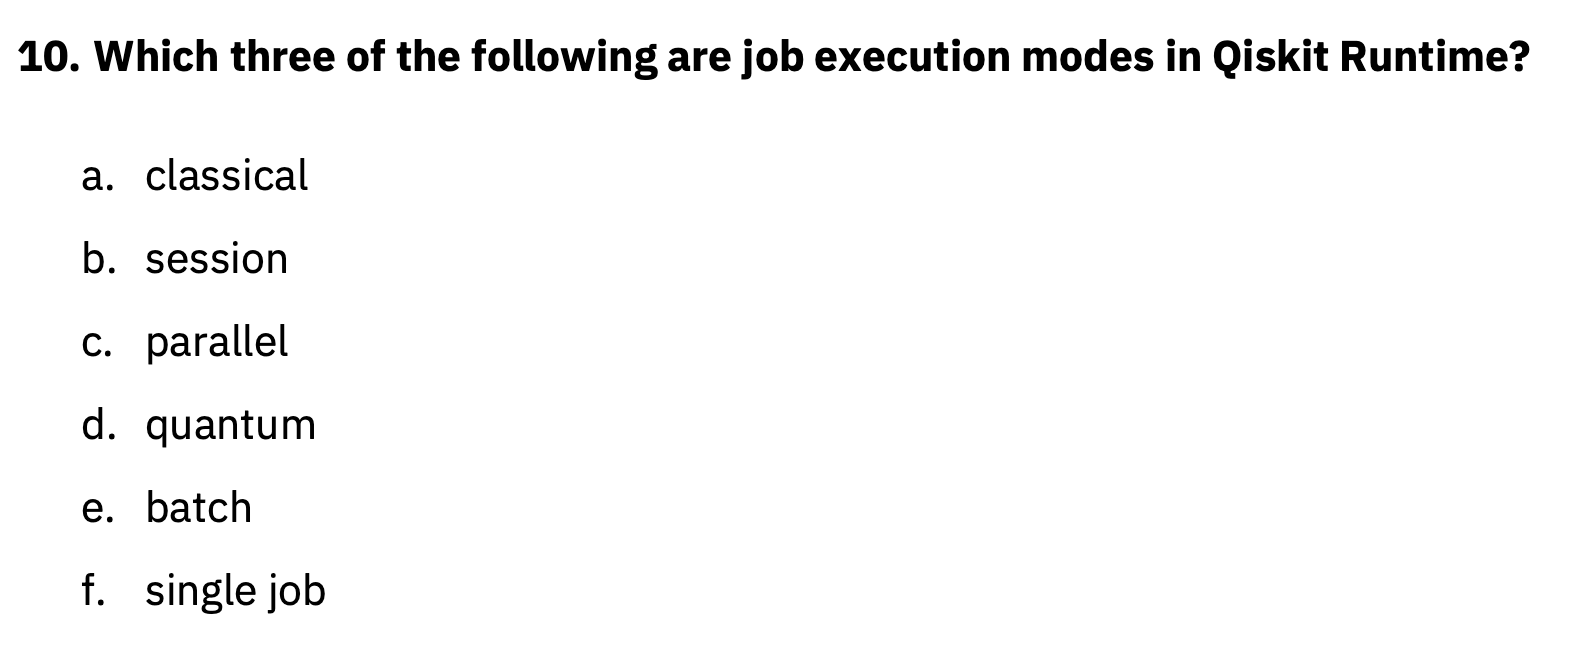

<!-- b, e, f -->

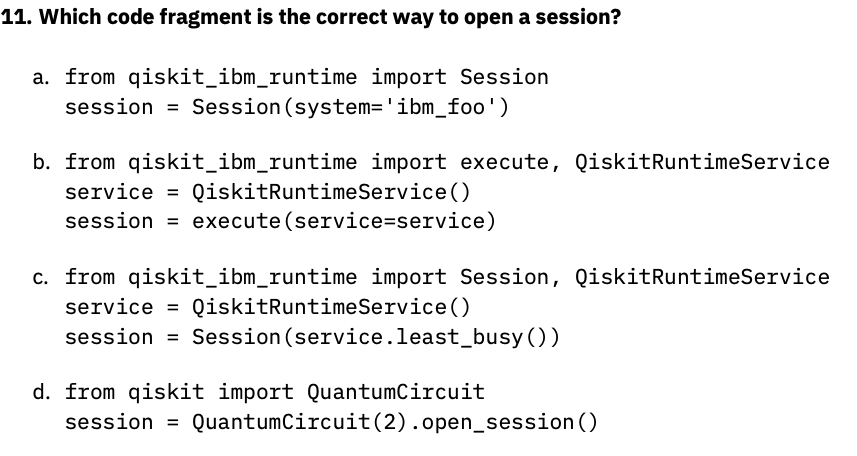

<!-- c -->

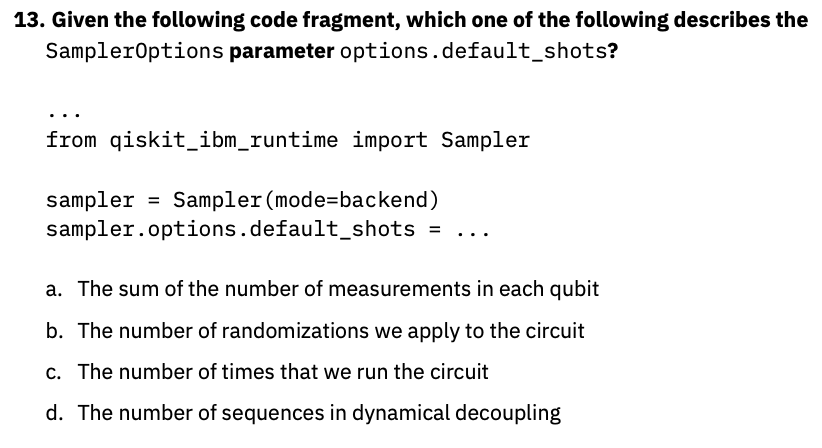

<!-- c -->

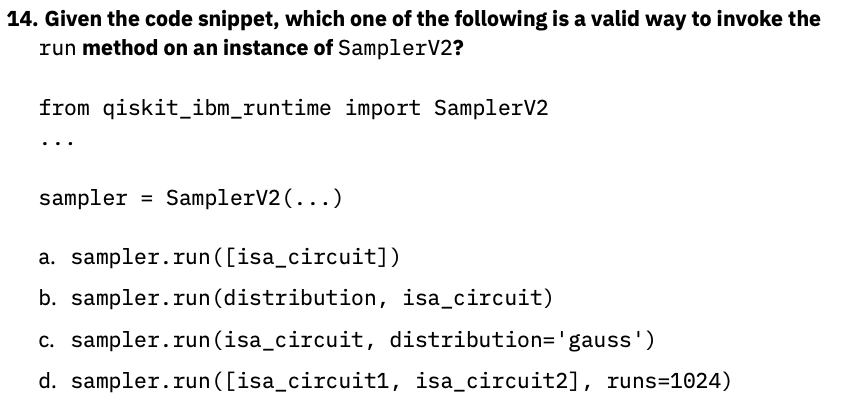

<!-- a -->

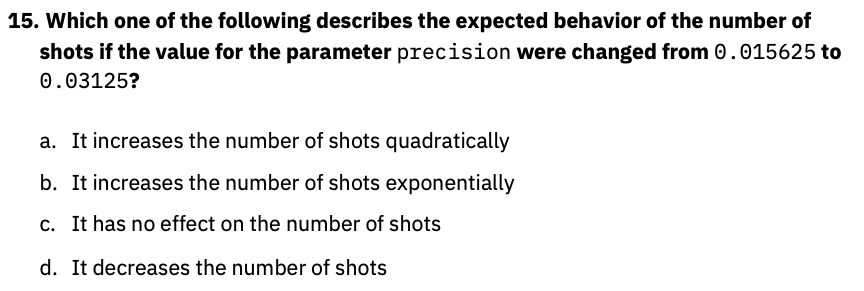

<!-- d -->

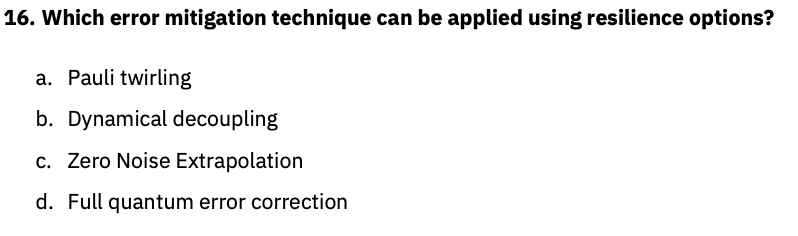

<!-- c -->

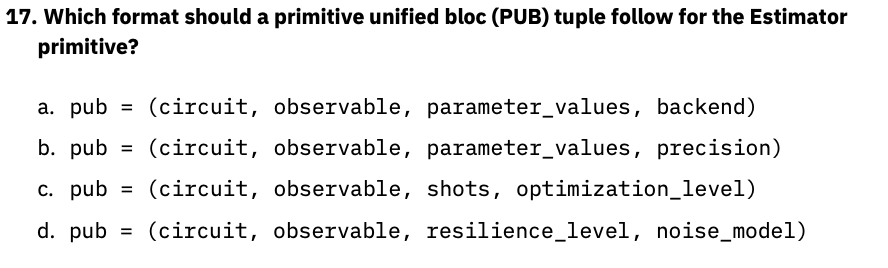

<!-- b -->